<a href="https://colab.research.google.com/github/Jagadeesh819/aiml/blob/main/Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler


In [8]:
np.random.seed(42)
data = {
    'Age': np.random.randint(18, 65, 200),
    'Annual_Income': np.random.randint(15000, 100000, 200),
    'Spending_Score': np.random.randint(1, 100, 200)
}
df = pd.DataFrame(data)
df.head()


,Age,Annual_Income,Spending_Score
0,56,67733,99
1,46,80318,55
2,32,38664,40
3,60,82172,52
4,25,41736,16


In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(scaled_data)
df['Cluster'] = labels
df.head()


,Age,Annual_Income,Spending_Score,Cluster
0,56,67733,99,0
1,46,80318,55,1
2,32,38664,40,4
3,60,82172,52,1
4,25,41736,16,4


In [11]:
silhouette = silhouette_score(scaled_data, labels)
davies_bouldin = davies_bouldin_score(scaled_data, labels)
calinski_harabasz = calinski_harabasz_score(scaled_data, labels)

print("Clustering Evaluation Metrics:")
print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")


Clustering Evaluation Metrics:
Silhouette Score: 0.289
Davies-Bouldin Index: 1.045
Calinski-Harabasz Index: 81.013


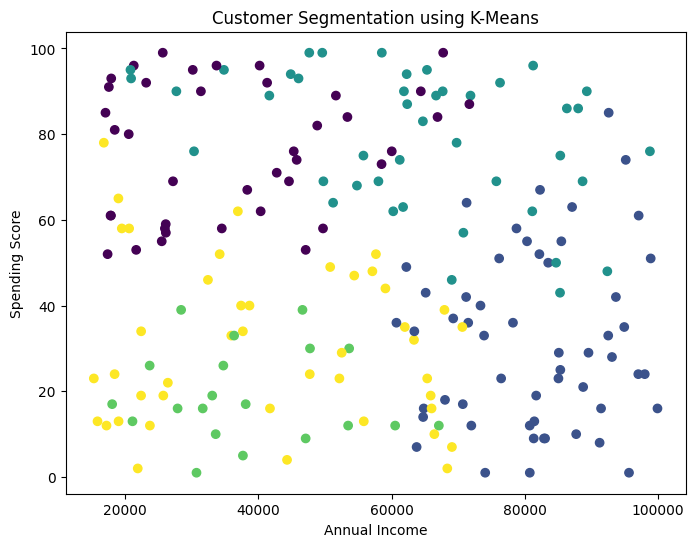

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'], cmap='viridis')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()
